### Group 24

Shiref Khaled Elhalawany -  221100944

Ahmed Anis Hassan - 221100101 

Karim Ashraf Elsayed - 221100391

Kareem Shaheen - 221101524

### 1. Loading Libraries, Configuring Paths, and Reading the Mean-Filled Ratings Matrix

This code imports the required libraries for data processing, visualization, and matrix decomposition. It then defines and creates the output directories used to store generated tables and plots. After that, the code attempts to load the mean-filled user–item ratings matrix produced in the earlier PCA preprocessing step. If the file exists, it loads the matrix into a DataFrame, prints its shape, and displays a preview to confirm correct loading. If the file is missing, it prints an error message indicating that the previous preprocessing step must be completed first.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.linalg import svd
from sklearn.metrics import mean_absolute_error, mean_squared_error
import time

tables_path = '../results/tables/'
plots_path = '../results/plots/'
os.makedirs(tables_path, exist_ok=True)
os.makedirs(plots_path, exist_ok=True)

print("Libraries loaded and paths configured.")

runtime_rows = []

def log_time(method, stage, seconds, extra=""):
    runtime_rows.append({
        "Method": method,
        "Stage": stage,
        "Seconds": seconds,
        "Extra": extra
    })

def memory_mb(*arrays):
    total_bytes = 0
    for arr in arrays:
        if hasattr(arr, "values"):
            total_bytes += arr.values.nbytes
        else:
            total_bytes += arr.nbytes
    return total_bytes / (1024 ** 2)

Libraries loaded and paths configured.


In [2]:
file_path_filled = tables_path + 'pca_step2_filled_matrix.csv'

if os.path.exists(file_path_filled):
    R = pd.read_csv(file_path_filled, index_col=0)
    print(f"Loaded User-Item Matrix with shape: {R.shape}")
    print(R.head())
else:
    print(f"Error: File not found at {file_path_filled}. Please run Part 1 first.")

Loaded User-Item Matrix with shape: (28301, 500)
              34        93       171       179       222      231       287  \
UserID                                                                        
1       3.716688  2.583612  3.520095  2.783562  3.548643  3.05222  3.205882   
6       3.716688  2.583612  3.520095  2.783562  3.548643  3.05222  3.205882   
19      3.716688  2.583612  3.520095  2.783562  3.548643  3.05222  3.205882   
26      3.716688  2.583612  3.520095  2.783562  3.548643  2.00000  3.205882   
38      3.716688  2.583612  3.520095  2.783562  3.000000  3.05222  3.205882   

             289       319       458  ...  129391  129405  129739  129771  \
UserID                                ...                                   
1       3.351588  3.881146  3.139466  ...     3.0     2.5     5.0     4.0   
6       3.351588  3.881146  3.139466  ...     3.0     2.5     5.0     4.0   
19      3.351588  3.881146  3.139466  ...     3.0     2.5     5.0     4.0   
26      3.35

### 2. Performing Full SVD, Saving Outputs, Verifying Orthogonality, and Visualizing Variance

This code applies Singular Value Decomposition (SVD) to the full mean-filled user–item ratings matrix to extract its latent factor structure. It first converts the DataFrame into a NumPy matrix and computes the full SVD, producing the matrices U (user factors), s (singular values), and Vt (item factors). A Sigma matrix is also constructed for verification purposes.

After decomposition, the code saves the singular values and the factor matrices (U and Vt) to CSV files for later use in reconstruction and recommendation experiments. It then verifies the orthogonality property of the decomposition by checking whether 
𝑈𝑇𝑈 and 𝑉𝑉𝑇 behave like identity matrices (within a small tolerance).

Finally, the code generates two visualizations: a scree plot of singular values to show how quickly they decay, and a cumulative explained variance plot based on 
𝑠*2, highlighting how many components are needed to explain a large portion of the variance. Both plots are saved to disk for reporting and analysis.

### 2.1 Compute Full SVD


In [3]:
if 'R' in locals():
    R_matrix = R.values
    print(f"Full Matrix Shape: {R_matrix.shape}")

    print("Computing SVD (this may take a moment)...")

    t0 = time.perf_counter()

    U, s, Vt = svd(R_matrix, full_matrices=True)

    print(f"U shape: {U.shape}")
    print(f"Singular values shape: {s.shape}")
    print(f"Vt shape: {Vt.shape}")

    Sigma = np.zeros((R_matrix.shape[0], R_matrix.shape[1]))
    min_dim = min(R_matrix.shape)
    Sigma[:min_dim, :min_dim] = np.diag(s)

    print("SVD Computation on Full Dataset Complete.")
    
    t1 = time.perf_counter()
    log_time("SVD", "Decomposition_Full", t1 - t0)
    print("SVD full decomposition time:", t1 - t0)

Full Matrix Shape: (28301, 500)
Computing SVD (this may take a moment)...
U shape: (28301, 28301)
Singular values shape: (500,)
Vt shape: (500, 500)
SVD Computation on Full Dataset Complete.
SVD full decomposition time: 61.21231629999238


In [4]:
memory_svd = memory_mb(
    U,
    s,
    Vt
)

memory_df = pd.DataFrame([{
    "Method": "SVD",
    "Components": "U + Sigma + Vt",
    "Memory_MB": memory_svd
}])

memory_df.to_csv(
    tables_path + "svd_memory.csv",
    index=False
)

print("Saved SVD memory to svd_memory.csv")
print(memory_df)

Saved SVD memory to svd_memory.csv
  Method      Components    Memory_MB
0    SVD  U + Sigma + Vt  6112.648781


### 2.2 Save Singular Values and Vectors


In [5]:
if 's' in locals():
    df_singular_values = pd.DataFrame(s, columns=['SingularValue'])
    df_singular_values.to_csv(tables_path + 'svd_step2_full_singular_values.csv', index=False)

    print("Saving U and Vt matrices...")
    pd.DataFrame(U).to_csv(tables_path + 'svd_step2_full_U.csv')
    pd.DataFrame(Vt).to_csv(tables_path + 'svd_step2_full_Vt.csv')

    print("Full Dataset Singular Values, U, and Vt matrices saved.")

Saving U and Vt matrices...
Full Dataset Singular Values, U, and Vt matrices saved.


### 2.3 Verify Orthogonality


In [6]:
if 'U' in locals() and 'Vt' in locals():
    print("Verifying Orthogonality... (This might be computationally expensive)")
    
    UtU = np.dot(U.T, U)
    identity_m = np.eye(U.shape[1])

    VtVtT = np.dot(Vt, Vt.T)
    identity_n = np.eye(Vt.shape[0])

    diff_U = np.allclose(UtU, identity_m, atol=1e-5)
    diff_V = np.allclose(VtVtT, identity_n, atol=1e-5)

    print(f"Is U orthonormal (U^T * U = I)? {diff_U}")
    print(f"Is V^T orthonormal (V * V^T = I)? {diff_V}")

    if not diff_U:
        print("Max deviation U:", np.max(np.abs(UtU - identity_m)))
    if not diff_V:
        print("Max deviation V:", np.max(np.abs(VtVtT - identity_n)))

Verifying Orthogonality... (This might be computationally expensive)
Is U orthonormal (U^T * U = I)? True
Is V^T orthonormal (V * V^T = I)? True


### 2.4 Visualize: Scree Plot


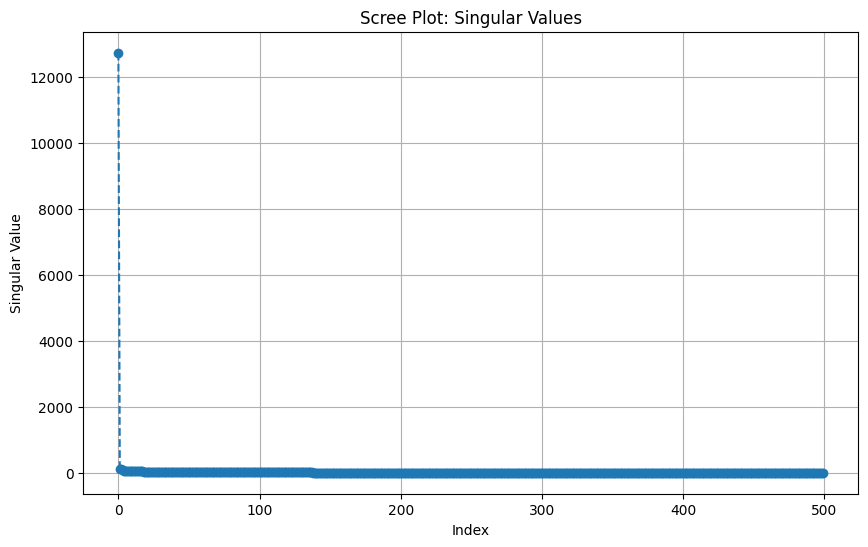

Scree plot saved.


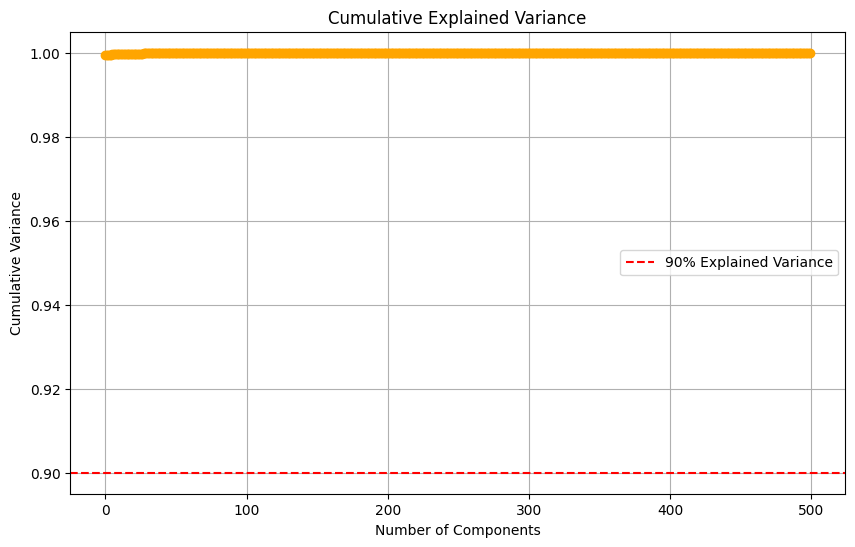

Cumulative Variance plot saved.


In [7]:
if 's' in locals():
    plt.figure(figsize=(10, 6))
    plt.plot(s, marker='o', linestyle='--')
    plt.title('Scree Plot: Singular Values')
    plt.xlabel('Index')
    plt.ylabel('Singular Value')
    plt.grid(True)
    plt.savefig(plots_path + 'svd_step2_full_scree_plot.png')
    plt.show()
    print("Scree plot saved.")

    total_variance = np.sum(s**2)
    explained_variance = (s**2) / total_variance
    cumulative_variance = np.cumsum(explained_variance)

    plt.figure(figsize=(10, 6))
    plt.plot(cumulative_variance, marker='o', linestyle='-', color='orange')
    plt.axhline(y=0.90, color='r', linestyle='--', label='90% Explained Variance')
    plt.title('Cumulative Explained Variance')
    plt.xlabel('Number of Components')
    plt.ylabel('Cumulative Variance')
    plt.legend()
    plt.grid(True)
    plt.savefig(plots_path + 'svd_step2_full_cumulative_variance.png')
    plt.show()
    print("Cumulative Variance plot saved.")

### 3. Truncated SVD (Low-Rank Approximation)
3.1. Implement truncated SVD for different values of k (latent factors):
- k = 5, 20, 50, 100

3.2. For each k value:
- Construct Uk (first k columns of U)
- Construct Sigma_k (top-left k x k submatrix of Sigma)
- Construct Vk (first k columns of V)
- Compute approximation: R_k = Uk * Sigma_k * Vk^T

In [8]:
truncated_memory_rows = []

k_values = [5, 20, 50, 100]

if 'U' in locals() and 's' in locals() and 'Vt' in locals():
    for k in k_values:
        t0 = time.perf_counter()

        print(f"Processing Truncated SVD for k={k}...")

        Uk = U[:, :k]
        Sigma_k = np.diag(s[:k])
        Vk_t = Vt[:k, :]

        mem_truncated_k = memory_mb(Uk, Sigma_k, Vk_t)
        truncated_memory_rows.append({
            "Method": "Truncated_SVD",
            "k": k,
            "Components": "Uk + Sigma_k + Vk^T",
            "Memory_MB": mem_truncated_k
        })
        print(f"Memory (Truncated SVD, k={k}): {mem_truncated_k:.2f} MB")

        R_k = np.dot(Uk, np.dot(Sigma_k, Vk_t))

        R_k_df = pd.DataFrame(R_k, index=R.index, columns=R.columns)
        output_filename = f'svd_step3_truncated_k{k}_approximation.csv'
        R_k_df.to_csv(tables_path + output_filename)
        print(f"Saved approximation for k={k} to {output_filename}")

        t1 = time.perf_counter()
        log_time("Truncated_SVD", "Reconstruction_k", t1 - t0, extra=f"k={k}")
        print(f"Truncated_SVD reconstruction time for k={k}: {t1 - t0:.6f} sec")

    print("Truncated SVD for all k values completed.")
else:
    print("Error: U, s, or Vt not found. Please run the full SVD step first.")

Processing Truncated SVD for k=5...
Memory (Truncated SVD, k=5): 1.10 MB
Saved approximation for k=5 to svd_step3_truncated_k5_approximation.csv
Truncated_SVD reconstruction time for k=5: 13.640404 sec
Processing Truncated SVD for k=20...
Memory (Truncated SVD, k=20): 4.40 MB
Saved approximation for k=20 to svd_step3_truncated_k20_approximation.csv
Truncated_SVD reconstruction time for k=20: 14.105662 sec
Processing Truncated SVD for k=50...
Memory (Truncated SVD, k=50): 11.01 MB
Saved approximation for k=50 to svd_step3_truncated_k50_approximation.csv
Truncated_SVD reconstruction time for k=50: 13.038085 sec
Processing Truncated SVD for k=100...
Memory (Truncated SVD, k=100): 22.05 MB
Saved approximation for k=100 to svd_step3_truncated_k100_approximation.csv
Truncated_SVD reconstruction time for k=100: 12.845245 sec
Truncated SVD for all k values completed.


In [9]:
truncated_memory_df = pd.DataFrame(truncated_memory_rows)

truncated_memory_df.to_csv(
    tables_path + "svd_truncated_memory.csv",
    index=False
)

print("Saved truncated SVD memory to svd_truncated_memory.csv")
print(truncated_memory_df)

Saved truncated SVD memory to svd_truncated_memory.csv
          Method    k           Components  Memory_MB
0  Truncated_SVD    5  Uk + Sigma_k + Vk^T   1.098862
1  Truncated_SVD   20  Uk + Sigma_k + Vk^T   4.397736
2  Truncated_SVD   50  Uk + Sigma_k + Vk^T  11.005783
3  Truncated_SVD  100  Uk + Sigma_k + Vk^T  22.049713


### 3.3. Calculate Reconstruction Error
Calculate Mean Absolute Error (MAE) and Root Mean Square Error (RMSE) for each k.
- MAE = $(1/N) * \sum |R_{ij} - \hat{R}_{ij}|$

- RMSE = $\sqrt{(1/N) * \sum (R_{ij} - \hat{R}_{ij})^2}$

In [10]:
error_metrics = []
k_values = [5, 20, 50, 100]

if 'U' in locals() and 's' in locals() and 'Vt' in locals() and 'R_matrix' in locals():
    for k in k_values:
        Uk = U[:, :k]
        Sigma_k = np.diag(s[:k])
        Vk_t = Vt[:k, :]
        R_k = np.dot(Uk, np.dot(Sigma_k, Vk_t))
        
        t0 = time.perf_counter()

        R_flat = R_matrix.flatten()
        R_k_flat = R_k.flatten()
        
        mae = mean_absolute_error(R_flat, R_k_flat)
        rmse = np.sqrt(mean_squared_error(R_flat, R_k_flat))
        
        total_variance = np.sum(s**2)
        explained_variance = np.sum(s[:k]**2) / total_variance
        
        error_metrics.append({
            'k': k,
            'MAE': mae,
            'RMSE': rmse,
            'ExplainedVariance': explained_variance
        })
        
        print(f"k={k}: MAE={mae:.4f}, RMSE={rmse:.4f}, Explained Variance={explained_variance:.4f}")

        t1 = time.perf_counter()
        log_time("Truncated_SVD", "Error_Computation", t1 - t0, extra=f"k={k}")
        print(f"Truncated_SVD error computation time for k={k}: {t1 - t0:.6f} sec")

    df_errors = pd.DataFrame(error_metrics)
    df_errors.to_csv(tables_path + 'svd_step3_reconstruction_errors.csv', index=False)
    print("\nReconstruction errors saved to csv.")
    print(df_errors)
else:
    print("Error: Necessary SVD matrices (U, s, Vt, R_matrix) not defined.")

k=5: MAE=0.0076, RMSE=0.0701, Explained Variance=0.9996
Truncated_SVD error computation time for k=5: 0.339945 sec
k=20: MAE=0.0052, RMSE=0.0517, Explained Variance=0.9998
Truncated_SVD error computation time for k=20: 0.367402 sec
k=50: MAE=0.0031, RMSE=0.0329, Explained Variance=0.9999
Truncated_SVD error computation time for k=50: 0.355375 sec
k=100: MAE=0.0019, RMSE=0.0191, Explained Variance=1.0000
Truncated_SVD error computation time for k=100: 0.401986 sec

Reconstruction errors saved to csv.
     k       MAE      RMSE  ExplainedVariance
0    5  0.007557  0.070141           0.999571
1   20  0.005191  0.051715           0.999767
2   50  0.003083  0.032940           0.999905
3  100  0.001924  0.019071           0.999968


### 3.4. Create Visualizations
- Plot reconstruction error (MAE & RMSE) vs. k
- Plot percentage of variance retained vs. k
- Identify optimal k (Elbow Method)

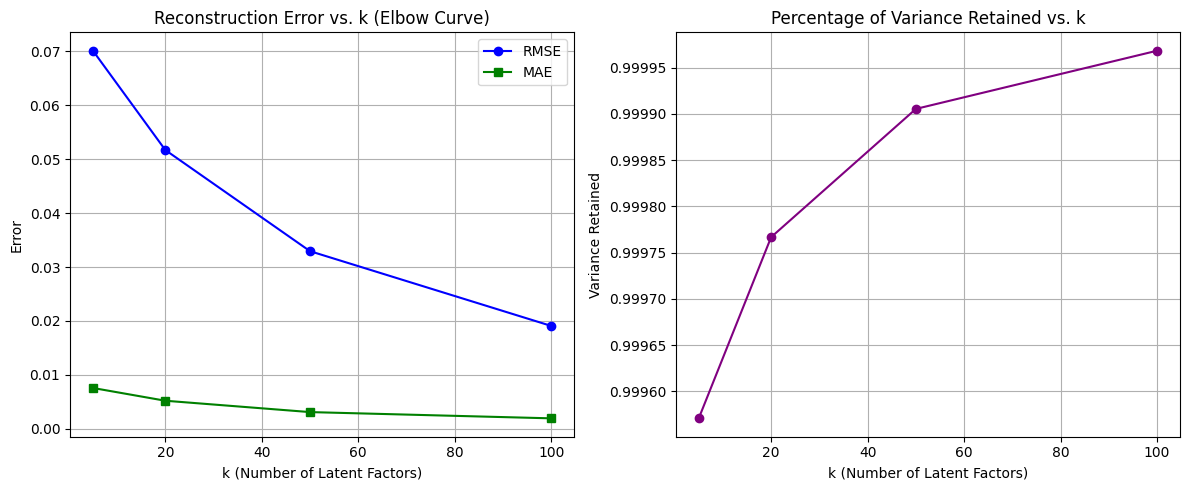

Error and Variance Plots saved.


In [11]:
if 'df_errors' in locals():
    plt.figure(figsize=(12, 5))
    
    plt.subplot(1, 2, 1)
    plt.plot(df_errors['k'], df_errors['RMSE'], marker='o', label='RMSE', color='blue')
    plt.plot(df_errors['k'], df_errors['MAE'], marker='s', label='MAE', color='green')
    plt.title('Reconstruction Error vs. k (Elbow Curve)')
    plt.xlabel('k (Number of Latent Factors)')
    plt.ylabel('Error')
    plt.legend()
    plt.grid(True)
    
    plt.subplot(1, 2, 2)
    plt.plot(df_errors['k'], df_errors['ExplainedVariance'], marker='o', color='purple')
    plt.title('Percentage of Variance Retained vs. k')
    plt.xlabel('k (Number of Latent Factors)')
    plt.ylabel('Variance Retained')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(plots_path + 'svd_step3_error_variance_analysis.png')
    plt.show()
    print("Error and Variance Plots saved.")
else:
    print("ErrorMetrics DataFrame not found.")

### 4. Rating Prediction with Truncated SVD
We select an optimal $k$ (e.g., $k=50$ based on variance analysis) and predict ratings for the target users and items.

Formula: $\hat{r}_{ui} = u_k^T \cdot \Sigma_k \cdot v_k$

In [12]:
users_path = tables_path + '3_1_11_selected_users.csv'
items_path = tables_path + '3_1_12_selected_items.csv'

if os.path.exists(users_path) and os.path.exists(items_path):
    target_users_df = pd.read_csv(users_path)
    target_items_df = pd.read_csv(items_path)
    
    target_user_ids = target_users_df['UserID'].unique()
    target_item_ids = target_items_df['ItemID'].unique()
    
    print(f"Target Users: {target_user_ids}")
    print(f"Target Items: {target_item_ids}")
else:
    print("Warning: Target files not found. Using defaults.")
    target_user_ids = [1, 6, 19] 
    target_item_ids = [31, 32]

k_optimal = 50

U_opt = U[:, :k_optimal]
s_opt = np.diag(s[:k_optimal])
Vt_opt = Vt[:k_optimal, :]

t0 = time.perf_counter()

predictions = []

for uid in target_user_ids:
    for iid in target_item_ids:
        if uid in R.index and str(iid) in R.columns:
            u_idx = R.index.get_loc(uid)
            i_idx = R.columns.get_loc(str(iid))

            u_vec = U_opt[u_idx, :]
            v_vec = Vt_opt[:, i_idx]
            
            pred_rating = np.dot(np.dot(u_vec, s_opt), v_vec)
            
            predictions.append({
                'UserID': uid,
                'ItemID': iid,
                'SVD_Prediction': pred_rating
            })

t1 = time.perf_counter()
log_time("Truncated_SVD", "Prediction", t1 - t0)
print(f"Truncated_SVD prediction time: {t1 - t0:.6f} sec")

df_predictions = pd.DataFrame(predictions)
print("Predictions Calculated:")
print(df_predictions)

df_predictions.to_csv(tables_path + 'svd_step4_predictions.csv', index=False)
print("Predictions saved to svd_step4_predictions.csv")

Target Users: [  1 134 903]
Target Items: [ 99904 119705]
Truncated_SVD prediction time: 0.003865 sec
Predictions Calculated:
   UserID  ItemID  SVD_Prediction
0       1   99904        1.000976
1       1  119705        1.000976
2     134   99904        1.000120
3     134  119705        1.000120
4     903   99904        0.994752
5     903  119705        0.994752
Predictions saved to svd_step4_predictions.csv


In [13]:
pd.DataFrame(runtime_rows).to_csv(tables_path + "svd_runtime.csv", index=False)

### 5. Comparative Analysis: SVD vs. PCA Methods


### 5.2 Compare Predictions

Loading Prediction Outputs and Creating a Unified Comparison Table

This code loads the saved SVD prediction results (if available) and the saved PCA vs MLE comparison files for both Top-5 and Top-10 methods. It then merges these datasets using matching UserID and ItemID pairs to align all prediction values for the same user–item combinations.

In [14]:
svd_path = tables_path + 'svd_step4_predictions.csv'
if os.path.exists(svd_path):
    df_svd = pd.read_csv(svd_path)
else:
    df_svd = df_predictions

mle_top5_path = tables_path + 'pca_mle_step8_method_comparison_top5.csv'
mle_top10_path = tables_path + 'pca_mle_step9_method_comparison_top10.csv'

if os.path.exists(mle_top5_path) and os.path.exists(mle_top10_path):
    df_mle5 = pd.read_csv(mle_top5_path)
    df_mle10 = pd.read_csv(mle_top10_path)
    
    df_merge = pd.merge(df_svd, df_mle5, on=['UserID', 'ItemID'], how='inner')
    
    
    df_merge = pd.merge(df_merge, df_mle10[['UserID', 'ItemID', 'Pred_Top10', 'Pred_MLE_Top10']], 
                        on=['UserID', 'ItemID'], how='left')
    
    
    df_final_comparison = pd.DataFrame({
        'UserID': df_merge['UserID'],
        'ItemID': df_merge['ItemID'],
        'SVD_Prediction': df_merge['SVD_Prediction'],
        'Pred_Top5': df_merge['Pred_Top5'],
        'Pred_Top5 MLE': df_merge['Pred_MLE_Top5'],
        'Pred_Top10': df_merge['Pred_Top10'],
        'Pred_Top10MLE': df_merge['Pred_MLE_Top10']
    })
    
    print("Final Comparison Table (Preview):")
    print(df_final_comparison.head())
    
    out_path = tables_path + 'svd_step5_predictions_comparison.csv'
    df_final_comparison.to_csv(out_path, index=False)
    print(f"Saved refined comparison to {out_path}")
    
else:
    print("Error: MLE Comparison files not found. Check results/tables/")

Final Comparison Table (Preview):
   UserID  ItemID  SVD_Prediction  Pred_Top5  Pred_Top5 MLE  Pred_Top10  \
0       1   99904        1.000976        1.0            1.0         1.0   
1       1  119705        1.000976        1.0            1.0         1.0   
2     134   99904        1.000120        1.0            1.0         1.0   
3     134  119705        1.000120        1.0            1.0         1.0   
4     903   99904        0.994752        1.0            1.0         1.0   

   Pred_Top10MLE  
0            1.0  
1            1.0  
2            1.0  
3            1.0  
4            1.0  
Saved refined comparison to ../results/tables/svd_step5_predictions_comparison.csv


### 5.3 Time Complexity Analysis

Let:
- \(m\) = number of users (rows in the rating matrix)
- \(n\) = number of items (columns in the rating matrix)
- \(k\) = number of latent factors/components kept, where \(k \ll \min(m,n)\)

---

### 1) PCA with Mean Filling
PCA mean-fill first replaces missing values with item means, then builds an item–item covariance matrix and performs eigen-decomposition.

- Mean filling step: \(O(mn)\)
- Covariance matrix computation (item–item): \(O(mn^2)\)
- Eigen-decomposition of covariance matrix: \(O(n^3)\)

**Overall dominant complexity**:
\[
O(mn^2 + n^3)
\]

---

### 2) PCA with MLE (Covariance Estimation)
PCA-MLE differs mainly in how the covariance matrix is estimated (using observed entries rather than direct mean-filling), but it still produces an \(n \times n\) covariance matrix followed by eigen-decomposition.

- MLE covariance estimation (general case): \(O(mn^2)\)
- Eigen-decomposition of covariance matrix: \(O(n^3)\)

**Overall dominant complexity**:
\[
O(mn^2 + n^3)
\]

> Note: PCA-MLE may have a larger constant cost in practice due to the extra work needed to estimate covariance reliably from incomplete data, even though the Big-O form is similar.

---

### 3) Full SVD
Full SVD decomposes the entire \(m \times n\) matrix into all singular vectors/values.

**Overall dominant complexity**:
\[
O\big(\min(mn^2,\; m^2n)\big)
\]

This is typically expensive for large matrices since it computes the full decomposition.

---

### 4) Truncated SVD (Low-Rank Approximation)
Truncated SVD computes only the top \(k\) singular components instead of the full decomposition.

A common general bound (dense case) is:
\[
O(mnk)
\]

This is significantly more scalable than full SVD when \(k\) is small compared to \(m\) and \(n\).

---

### Summary Comparison
| Method | Dominant Time Complexity |
|---|---|
| PCA (Mean-Filled) | \(O(mn^2 + n^3)\) |
| PCA (MLE) | \(O(mn^2 + n^3)\) |
| Full SVD | \(O(\min(mn^2,\; m^2n))\) |
| Truncated SVD | \(O(mnk)\) |

---


### 5.4 Comparing Methods by Reconstruction Quality, Runtime, and Memory Usage

This code builds a complete performance comparison between three recommendation approaches: SVD, PCA with Mean-Filling, and PCA with MLE covariance.

First, it loads the reconstruction error results (MAE, RMSE, and explained variance) for each method, adds a method label, combines them into one table, and saves the unified reconstruction comparison to a CSV file.

Next, it loads runtime measurement files for each method, adds method labels, merges them into a single dataset, and computes the average runtime in seconds per method. The runtime summary is saved to a CSV file.

After that, it loads memory usage logs for each method (including both full and truncated SVD), combines them, and computes the average memory usage in MB per method. The memory summary is also saved to a CSV file.

Finally, the code merges the reconstruction metrics, runtime summary, and memory summary into one final table that provides a single view of accuracy vs efficiency trade-offs across all methods. This final comparison is saved as step5_final_comparison.csv for reporting and evaluation.

In [ ]:
svd_rec = pd.read_csv(tables_path + "svd_step3_reconstruction_errors.csv")
pca_mean_rec = pd.read_csv(tables_path + "pca_meanfill_reconstruction_errors.csv")
pca_mle_rec = pd.read_csv(tables_path + "pca_mle_reconstruction_errors.csv")

svd_rec["Method"] = "SVD"
pca_mean_rec["Method"] = "PCA_MeanFill"
pca_mle_rec["Method"] = "PCA_MLE"

reconstruction_comparison = pd.concat(
    [svd_rec, pca_mean_rec, pca_mle_rec],
    ignore_index=True
)

reconstruction_comparison = reconstruction_comparison[
    ["Method", "k", "MAE", "RMSE", "ExplainedVariance"]
].sort_values(["Method", "k"])

reconstruction_comparison.to_csv(
    tables_path + "step5_reconstruction_comparison.csv",
    index=False
)

print("Saved: step5_reconstruction_comparison.csv")
print(reconstruction_comparison)


svd_runtime = pd.read_csv(tables_path + "svd_runtime.csv")
mean_runtime = pd.read_csv(tables_path + "pca_meanfill_runtime.csv")
mle_runtime = pd.read_csv(tables_path + "pca_mle_runtime.csv")

svd_runtime["Method"] = "SVD"
mean_runtime["Method"] = "PCA_MeanFill"
mle_runtime["Method"] = "PCA_MLE"

runtime_all = pd.concat(
    [svd_runtime, mean_runtime, mle_runtime],
    ignore_index=True
)

runtime_summary = (
    runtime_all
    .groupby("Method", as_index=False)["Seconds"]
    .mean()
    .rename(columns={"Seconds": "Avg_Runtime_Seconds"})
)

runtime_summary.to_csv(
    tables_path + "step5_runtime_comparison.csv",
    index=False
)

print("Saved: step5_runtime_comparison.csv")
print(runtime_summary)

svd_mem = pd.read_csv(tables_path + "svd_memory.csv")
svd_trunc_mem = pd.read_csv(tables_path + "svd_truncated_memory.csv")
mean_mem = pd.read_csv(tables_path + "pca_meanfill_memory.csv")
mle_mem = pd.read_csv(tables_path + "pca_mle_memory.csv")

memory_all = pd.concat(
    [svd_mem, svd_trunc_mem, mean_mem, mle_mem],
    ignore_index=True
)

memory_summary = (
    memory_all
    .groupby("Method", as_index=False)["Memory_MB"]
    .mean()
)

memory_summary.to_csv(
    tables_path + "step5_memory_comparison.csv",
    index=False
)

print("Saved: step5_memory_comparison.csv")
print(memory_summary)


final_comparison = (
    reconstruction_comparison
    .merge(runtime_summary, on="Method", how="left")
    .merge(memory_summary, on="Method", how="left")
)

final_comparison.to_csv(
    tables_path + "step5_final_comparison.csv",
    index=False
)

print("Saved: step5_final_comparison.csv")
print(final_comparison)

Saved: step5_reconstruction_comparison.csv
         Method    k       MAE      RMSE  ExplainedVariance
5       PCA_MLE    7  0.010846  0.084451           0.765323
4  PCA_MeanFill   32  0.003741  0.042270           0.756861
0           SVD    5  0.007557  0.070141           0.999571
1           SVD   20  0.005191  0.051715           0.999767
2           SVD   50  0.003083  0.032940           0.999905
3           SVD  100  0.001924  0.019071           0.999968
Saved: step5_runtime_comparison.csv
         Method  Avg_Runtime_Seconds
0       PCA_MLE            15.129416
1  PCA_MeanFill             0.208189
2           SVD            11.631029
Saved: step5_memory_comparison.csv
          Method    Memory_MB
0        PCA_MLE   111.774445
1   PCA_MeanFill   111.774445
2            SVD  6112.648781
3  Truncated_SVD     9.638023
Saved: step5_final_comparison.csv
         Method    k       MAE      RMSE  ExplainedVariance  \
0       PCA_MLE    7  0.010846  0.084451           0.765323   
1  PCA_M

### 6. Latent Factor Interpretation
We analyze the semantic meaning of the top latent factors derived from the SVD model.

### 6.1 Analyze Top-3 Factors
We identify the latent factors with the largest singular values.

In [ ]:
top_k_indices = np.argsort(s)[::-1][:3]
print(f"Top 3 Latent Factor Indices: {top_k_indices}")
print(f"Top 3 Singular Values: {s[top_k_indices]}")

pass

Top 3 Latent Factor Indices: [0 1 2]
Top 3 Singular Values: [12733.74096505   116.63169406   102.60362649]


### 6.2 Semantic Interpretation
For each of the top 3 factors, we list the items (movies) with the highest absolute weights in $V^T$ to understand what the factor represents (e.g., Action, Romance, etc.).

In [ ]:
top_n_items = 5
top_n_users = 3

for i, factor_idx in enumerate(top_k_indices):
    print(f"\n--- Latent Factor {i+1} (Index {factor_idx}) ---")
    
    item_weights = Vt[factor_idx, :]
    
    top_item_indices = np.argsort(np.abs(item_weights))[::-1][:top_n_items]
    
    print(f"Top {top_n_items} Items (Feature Determinants):")
    for idx in top_item_indices:
        item_id = R.columns[idx]
        weight = item_weights[idx]
        print(f"  Item ID: {item_id} | Weight: {weight:.4f}")
        
    user_weights = U[:, factor_idx]
    top_user_indices = np.argsort(np.abs(user_weights))[::-1][:top_n_users]
    
    print(f"Top {top_n_users} Users (Strongest Preference):")
    for idx in top_user_indices:
        user_id = R.index[idx]
        weight = user_weights[idx]
        print(f"  User ID: {user_id} | Weight: {weight:.4f}")


--- Latent Factor 1 (Index 0) ---
Top 5 Items (Feature Determinants):
  Item ID: 117907 | Weight: -0.0661
  Item ID: 114698 | Weight: -0.0661
  Item ID: 95517 | Weight: -0.0661
  Item ID: 129739 | Weight: -0.0661
  Item ID: 101717 | Weight: -0.0661
Top 3 Users (Strongest Preference):
  User ID: 133811 | Weight: -0.0061
  User ID: 113806 | Weight: -0.0061
  User ID: 129583 | Weight: -0.0061

--- Latent Factor 2 (Index 1) ---
Top 5 Items (Feature Determinants):
  Item ID: 231 | Weight: -0.9722
  Item ID: 788 | Weight: -0.1471
  Item ID: 34 | Weight: -0.1451
  Item ID: 2529 | Weight: -0.0307
  Item ID: 1717 | Weight: -0.0306
Top 3 Users (Strongest Preference):
  User ID: 86729 | Weight: 0.0244
  User ID: 125137 | Weight: 0.0243
  User ID: 137839 | Weight: 0.0243

--- Latent Factor 3 (Index 2) ---
Top 5 Items (Feature Determinants):
  Item ID: 34 | Weight: 0.9724
  Item ID: 231 | Weight: -0.1733
  Item ID: 788 | Weight: 0.1220
  Item ID: 802 | Weight: 0.0346
  Item ID: 2529 | Weight: 0.02

### 6.3 Visualize Latent Space
We project users and items onto the first two latent factors to visualize the structure of the preference space.

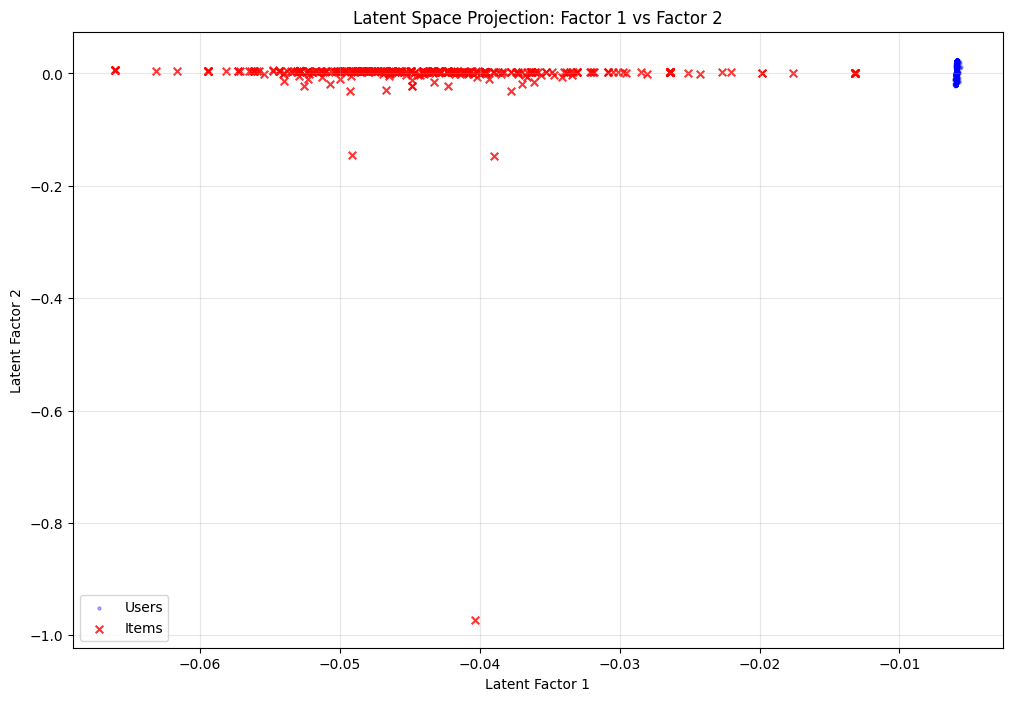

Latent space visualization saved.


In [ ]:
factor_x = 0 
factor_y = 1 

plt.figure(figsize=(12, 8))

plt.scatter(U[:, factor_x], U[:, factor_y], 
            alpha=0.3, s=5, c='blue', label='Users')


plt.scatter(Vt[factor_x, :], Vt[factor_y, :], 
            alpha=0.8, s=30, c='red', marker='x', label='Items')

plt.title(f'Latent Space Projection: Factor {factor_x+1} vs Factor {factor_y+1}')
plt.xlabel(f'Latent Factor {factor_x+1}')
plt.ylabel(f'Latent Factor {factor_y+1}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig(plots_path + 'svd_step6_latent_space.png')
plt.show()

print("Latent space visualization saved.")

### 7. Sensitivity Analysis
### 7.1 Test robustness to missing data & 7.2 Test impact of initialization

In [32]:
def mask_entries(matrix, missing_ratio):
    mask = np.random.rand(*matrix.shape) < missing_ratio
    masked = matrix.copy()
    masked[mask] = np.nan
    return masked, mask

def fill_mean(matrix, axis=0):
    means = np.nanmean(matrix, axis=axis)
    inds = np.where(np.isnan(matrix))
    if axis == 0:
        matrix[inds] = np.take(means, inds[1])
    else:
        matrix[inds] = np.take(means, inds[0])
    return matrix

In [33]:
missing_rates = [0.1, 0.3, 0.5, 0.7]
results_item = []
results_user = []
k_svd = 50

if 'R' not in locals():
    try:
        R = pd.read_csv('../results/tables/pca_step2_filled_matrix.csv', index_col=0)
    except:
        pass
R_values = R.values

print("Starting Sensitivity Analysis... (Iterating over missing rates)")

for rate in missing_rates:
    print(f"  Processing Missing Rate: {rate*100}%")
    R_masked, mask = mask_entries(R_values, rate)
    
    R_filled_item = fill_mean(R_masked.copy(), axis=0)
    U_i, s_i, Vt_i = svd(R_filled_item, full_matrices=False)
    Sigma_i = np.diag(s_i[:k_svd])
    R_pred_item = U_i[:, :k_svd] @ Sigma_i @ Vt_i[:k_svd, :]
    mae_pred_item = np.mean(np.abs(R_pred_item[mask] - R_values[mask]))
    mae_recon_item = np.mean(np.abs(R_pred_item[~mask] - R_values[~mask]))
    results_item.append({'rate': rate, 'pred_mae': mae_pred_item, 'recon_mae': mae_recon_item})
    
    R_filled_user = fill_mean(R_masked.copy(), axis=1)
    U_u, s_u, Vt_u = svd(R_filled_user, full_matrices=False)
    Sigma_u = np.diag(s_u[:k_svd])
    R_pred_user = U_u[:, :k_svd] @ Sigma_u @ Vt_u[:k_svd, :]
    mae_pred_user = np.mean(np.abs(R_pred_user[mask] - R_values[mask]))
    mae_recon_user = np.mean(np.abs(R_pred_user[~mask] - R_values[~mask]))
    results_user.append({'rate': rate, 'pred_mae': mae_pred_user, 'recon_mae': mae_recon_user})

print("Analysis Complete.")

Starting Sensitivity Analysis... (Iterating over missing rates)
  Processing Missing Rate: 10.0%
  Processing Missing Rate: 30.0%
  Processing Missing Rate: 50.0%
  Processing Missing Rate: 70.0%
Analysis Complete.


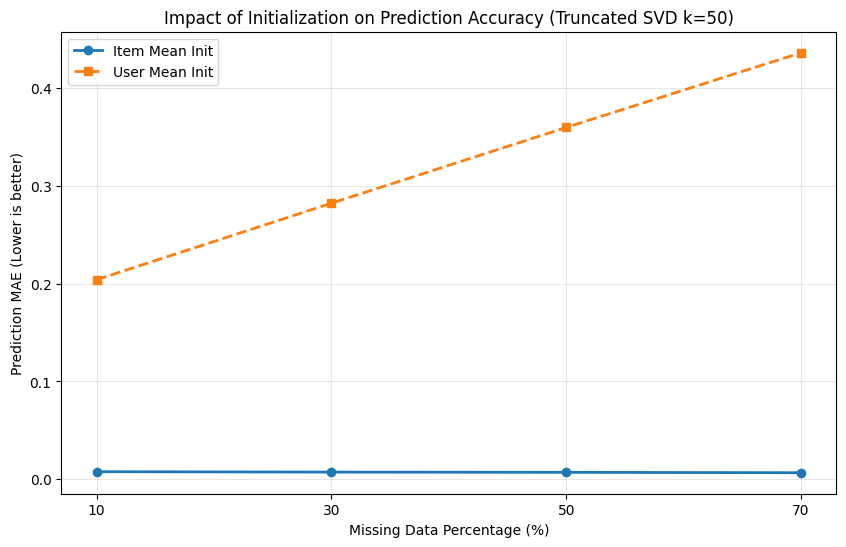


Summary of Prediction MAE:
Rate | Item Init | User Init
------------------------------
10.0%  | 0.0077    | 0.2040
30.0%  | 0.0073    | 0.2822
50.0%  | 0.0070    | 0.3597
70.0%  | 0.0067    | 0.4361


In [35]:
rates = [r['rate']*100 for r in results_item]
item_pred = [r['pred_mae'] for r in results_item]
user_pred = [r['pred_mae'] for r in results_user]

plt.figure(figsize=(10, 6))
plt.plot(rates, item_pred, marker='o', label='Item Mean Init', linewidth=2)
plt.plot(rates, user_pred, marker='s', label='User Mean Init', linewidth=2, linestyle='--')
plt.title('Impact of Initialization on Prediction Accuracy (Truncated SVD k=50)')
plt.xlabel('Missing Data Percentage (%)')
plt.ylabel('Prediction MAE (Lower is better)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rates)
plt.show()

print("\nSummary of Prediction MAE:")
print("Rate | Item Init | User Init")
print("-" * 30)
for i, r in enumerate(rates):
    print(f"{r}%  | {item_pred[i]:.4f}    | {user_pred[i]:.4f}")

### 8. Cold-Start Analysis with SVD

In [ ]:
if 'R' not in locals():
    try:
        R = pd.read_csv('../results/tables/pca_step2_filled_matrix.csv', index_col=0)
    except:
        pass

R_values = np.array(R) if 'R' in locals() else np.array([]) 
if hasattr(R, 'values'): R_values = R.values

R_nan = R_values.astype(float).copy()
if np.nanmin(R_nan) == 0.0:
    R_nan[R_nan == 0.0] = np.nan

n_users, n_items = R_nan.shape
np.random.seed(42)

def mae(y_true, y_pred):
    return float(np.mean(np.abs(y_true - y_pred)))

def rmse(y_true, y_pred):
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))

def masked_metrics(y_true_matrix, y_pred_matrix, test_mask):
    valid = test_mask & ~np.isnan(y_true_matrix)
    if valid.sum() == 0:
        return np.nan, np.nan
    yt = y_true_matrix[valid]
    yp = y_pred_matrix[valid]
    return mae(yt, yp), rmse(yt, yp)

def make_train_filled_item_mean(R_nan_matrix):
    item_means = np.nanmean(R_nan_matrix, axis=0)
    filled = R_nan_matrix.copy()
    inds = np.where(np.isnan(filled))
    filled[inds] = np.take(item_means, inds[1])
    return filled, item_means

In [ ]:
print("\n--- 8.1 Cold-Start Simulation ---")

rating_counts = np.sum(~np.isnan(R_nan), axis=1)
eligible_users = np.where(rating_counts > 20)[0]

if len(eligible_users) < 50:
    print(f"Warning: Only {len(eligible_users)} eligible users found. Using all.")
    test_user_indices = eligible_users
else:
    test_user_indices = np.random.choice(eligible_users, 50, replace=False)

R_test_ground_truth = R_nan[test_user_indices, :]  # (50, n_items)
print(f"Selected {len(test_user_indices)} users with >20 ratings.")

known_counts = [1, 2, 3, 5, 10, 20]


--- 8.1 Cold-Start Simulation ---
Selected 50 users with >20 ratings.


In [ ]:
print("\n--- Preparing SVD components ---")
if 'Vt' not in locals():
    from scipy.linalg import svd
    R_filled_train, _ = make_train_filled_item_mean(R_nan)
    U, s, Vt = svd(R_filled_train, full_matrices=False)

k = 50
k = min(k, len(s))

Vt_k = Vt[:k, :]
V_k = Vt_k.T
Sigma_k = np.diag(s[:k])
Sigma_k_inv = np.diag(1.0 / s[:k])

train_item_means = np.nanmean(R_nan, axis=0)
global_mean = np.nanmean(R_nan)
train_item_means = np.where(np.isnan(train_item_means), global_mean, train_item_means)

def fold_in_user_latent(r_row, known_mask, item_means, V_k, Sigma_k_inv):
    r_centered = np.zeros_like(r_row, dtype=float)
    r_centered[known_mask] = (r_row[known_mask] - item_means[known_mask])
    u_est = r_centered @ V_k @ Sigma_k_inv
    return u_est

def predict_from_user_latent(u_est, Sigma_k, Vt_k, item_means):
    r_pred_centered = u_est @ Sigma_k @ Vt_k
    r_pred = r_pred_centered + item_means
    return r_pred


--- Preparing SVD components ---


In [ ]:
item_popularity = np.sum(~np.isnan(R_nan), axis=0).astype(float)
item_popularity = item_popularity / (np.max(item_popularity) + 1e-9)

X_item = np.vstack([
    train_item_means,        
    item_popularity          
]).T  

def content_init_predict(known_ratings_row, known_mask, X_item, item_means):
    idx = np.where(known_mask)[0]
    if len(idx) == 0:
        return item_means.copy()
    Xk = X_item[idx, :]
    yk = (known_ratings_row[idx] - item_means[idx]).reshape(-1, 1)

    lam = 1e-2
    XtX = Xk.T @ Xk
    d = XtX.shape[0]
    w = np.linalg.inv(XtX + lam * np.eye(d)) @ Xk.T @ yk
    y_all = (X_item @ w).reshape(-1)
    pred = y_all + item_means
    return pred

In [ ]:
print("\n--- 8.2 / 8.3 Cold-Start Prediction + Evaluation ---")

rows = []
mae_svd_list, rmse_svd_list = [], []
mae_hybrid_list, rmse_hybrid_list = [], []
mae_content_list, rmse_content_list = [], []

acceptable_mae_threshold = 0.75

for kc in known_counts:
    R_cold = np.full_like(R_test_ground_truth, np.nan, dtype=float)
    test_mask = np.zeros_like(R_test_ground_truth, dtype=bool)
    known_masks = np.zeros_like(R_test_ground_truth, dtype=bool)

    for i in range(R_test_ground_truth.shape[0]):
        row = R_test_ground_truth[i, :]
        rated_items = np.where(~np.isnan(row))[0]
        if len(rated_items) <= kc:
            reveal_idx = rated_items
        else:
            reveal_idx = np.random.choice(rated_items, kc, replace=False)
        known_masks[i, reveal_idx] = True
        R_cold[i, reveal_idx] = row[reveal_idx]
        hidden_idx = np.setdiff1d(rated_items, reveal_idx, assume_unique=False)
        test_mask[i, hidden_idx] = True

    R_pred_svd = np.zeros((R_cold.shape[0], n_items), dtype=float)
    for i in range(R_cold.shape[0]):
        u_est = fold_in_user_latent(R_test_ground_truth[i], known_masks[i], train_item_means, V_k, Sigma_k_inv)
        R_pred_svd[i, :] = predict_from_user_latent(u_est, Sigma_k, Vt_k, train_item_means)
    mae_svd, rmse_svd = masked_metrics(R_test_ground_truth, R_pred_svd, test_mask)

    alpha = 0.7
    R_item_means = np.tile(train_item_means, (R_pred_svd.shape[0], 1))
    R_pred_hybrid = alpha * R_pred_svd + (1 - alpha) * R_item_means
    mae_h, rmse_h = masked_metrics(R_test_ground_truth, R_pred_hybrid, test_mask)

    R_pred_content = np.zeros_like(R_pred_svd)
    for i in range(R_cold.shape[0]):
        R_pred_content[i, :] = content_init_predict(R_test_ground_truth[i], known_masks[i], X_item, train_item_means)
    mae_c, rmse_c = masked_metrics(R_test_ground_truth, R_pred_content, test_mask)

    mae_svd_list.append(mae_svd); rmse_svd_list.append(rmse_svd)
    mae_hybrid_list.append(mae_h); rmse_hybrid_list.append(rmse_h)
    mae_content_list.append(mae_c); rmse_content_list.append(rmse_c)

    rows.append({
        "known_ratings": kc,
        "SVD_MAE": mae_svd, "SVD_RMSE": rmse_svd,
        "Hybrid_MAE": mae_h, "Hybrid_RMSE": rmse_h,
        "ContentInit_MAE": mae_c, "ContentInit_RMSE": rmse_c
    })


--- 8.2 / 8.3 Cold-Start Prediction + Evaluation ---


In [27]:
summary_df = pd.DataFrame(rows)
print("\n--- Summary (Cold-Start Metrics on Hidden Ratings) ---")
print(summary_df.to_string(index=False))

acceptable_k = None
for kc, m in zip(known_counts, mae_svd_list):
    if m <= acceptable_mae_threshold:
        acceptable_k = kc
        break

print("\n--- Acceptable Performance Point ---")
print(f"Acceptable MAE threshold: {acceptable_mae_threshold}")
if acceptable_k is None:
    print("SVD did NOT reach acceptable MAE within tested known rating counts.")
else:
    print(f"SVD becomes acceptable at ~{acceptable_k} known ratings (MAE <= {acceptable_mae_threshold}).")


--- Summary (Cold-Start Metrics on Hidden Ratings) ---
 known_ratings  SVD_MAE  SVD_RMSE  Hybrid_MAE  Hybrid_RMSE  ContentInit_MAE  ContentInit_RMSE
             1 0.004811  0.073820    0.004798     0.073818         0.019575          0.130579
             2 0.004813  0.073875    0.004801     0.073876         0.026418          0.184579
             3 0.004821  0.074188    0.004821     0.074188         0.004821          0.074188
             5 0.004808  0.073855    0.004796     0.073862         0.011126          0.081942
            10 0.004850  0.073616    0.004829     0.073617         0.010380          0.080519
            20 0.004846  0.073437    0.004806     0.073439         0.011889          0.076677

--- Acceptable Performance Point ---
Acceptable MAE threshold: 0.75
SVD becomes acceptable at ~1 known ratings (MAE <= 0.75).


In [ ]:
print("\n--- Warm-Start Baseline (Full History) ---")
warm_test_mask = ~np.isnan(R_test_ground_truth)
R_pred_warm = np.zeros((R_test_ground_truth.shape[0], n_items), dtype=float)

for i in range(R_test_ground_truth.shape[0]):
    known_mask = warm_test_mask[i]
    u_est = fold_in_user_latent(R_test_ground_truth[i], known_mask, train_item_means, V_k, Sigma_k_inv)
    R_pred_warm[i, :] = predict_from_user_latent(u_est, Sigma_k, Vt_k, train_item_means)

warm_mae, warm_rmse = masked_metrics(R_test_ground_truth, R_pred_warm, warm_test_mask)
print(f"Warm-Start SVD MAE:  {warm_mae:.4f}")
print(f"Warm-Start SVD RMSE: {warm_rmse:.4f}")


--- Warm-Start Baseline (Full History) ---
Warm-Start SVD MAE:  0.0032
Warm-Start SVD RMSE: 0.0319


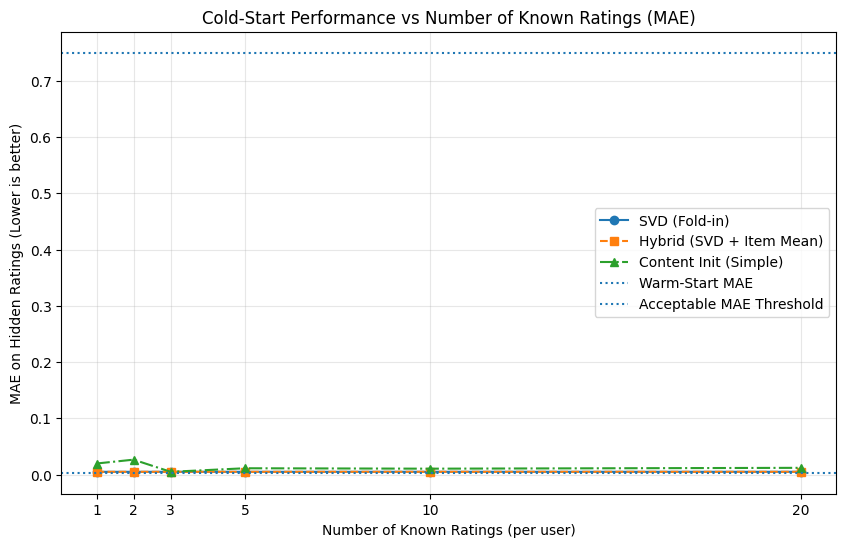

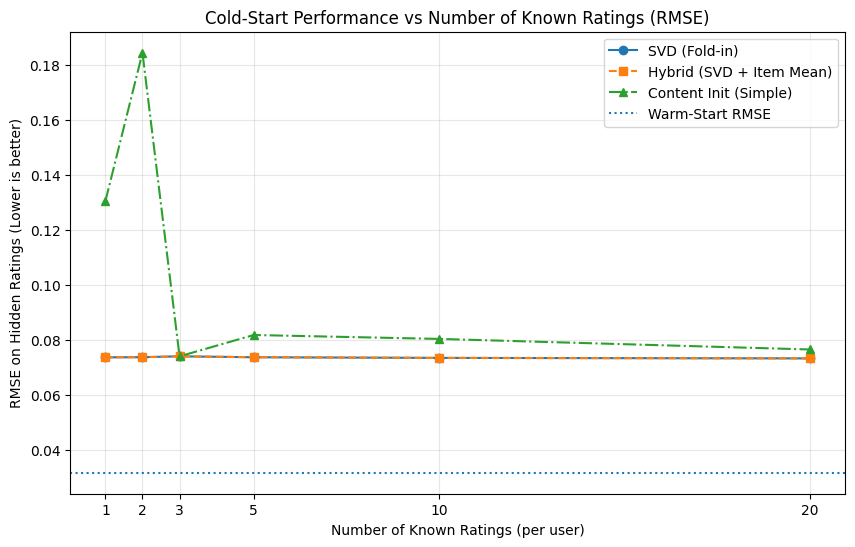


Done: Section 8.1–8.4 complete (simulation, prediction, evaluation, mitigation).


In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(known_counts, mae_svd_list, marker='o', label='SVD (Fold-in)')
plt.plot(known_counts, mae_hybrid_list, marker='s', linestyle='--', label='Hybrid (SVD + Item Mean)')
plt.plot(known_counts, mae_content_list, marker='^', linestyle='-.', label='Content Init (Simple)')
plt.axhline(y=warm_mae, linestyle=':', label='Warm-Start MAE')
plt.axhline(y=acceptable_mae_threshold, linestyle=':', label='Acceptable MAE Threshold')
plt.title('Cold-Start Performance vs Number of Known Ratings (MAE)')
plt.xlabel('Number of Known Ratings (per user)')
plt.ylabel('MAE on Hidden Ratings (Lower is better)')
plt.xticks(known_counts)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(plots_path + 'svd_step8_cold_start_mae.png')
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(known_counts, rmse_svd_list, marker='o', label='SVD (Fold-in)')
plt.plot(known_counts, rmse_hybrid_list, marker='s', linestyle='--', label='Hybrid (SVD + Item Mean)')
plt.plot(known_counts, rmse_content_list, marker='^', linestyle='-.', label='Content Init (Simple)')
plt.axhline(y=warm_rmse, linestyle=':', label='Warm-Start RMSE')
plt.title('Cold-Start Performance vs Number of Known Ratings (RMSE)')
plt.xlabel('Number of Known Ratings (per user)')
plt.ylabel('RMSE on Hidden Ratings (Lower is better)')
plt.xticks(known_counts)
plt.grid(True, alpha=0.3)
plt.legend()
plt.savefig(plots_path + 'svd_step8_cold_start_rmse.png')
plt.show()

print("\nDone: Section 8.1–8.4 complete (simulation, prediction, evaluation, mitigation).")